# --------------- Excercice 4-9 introduction to data visualisations

#### Creating libraries and path 

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
path = r'C:\Users\bouas\instacart bascket analysis'
grouping_data_order_product = pd.read_pickle(os.path.join(path, 'data', 'prepared_data', 'grouping_data_order_product.pkl'))


In [3]:
# checking df
grouping_data_order_product.columns 

Index(['Unnamed: 0', 'product_id', 'product_name', 'aisle_id', 'department_id',
       'prices', 'order_id', 'user_id', 'eval_set', 'order_number',
       'order_dow', 'order_hour_of_day', 'days_since_prior_order',
       'add_to_cart_order', 'reordered', '_merge', 'price_range_loc',
       'Busiest day', 'Busiest days', 'busiest_period_of_day', 'max_order',
       'loyalty_flag', 'mean_price', 'spending_flag',
       'median_days_since_last_orders', 'order_frequency_flag'],
      dtype='object')

In [4]:
df = grouping_data_order_product

##### creating bar chart

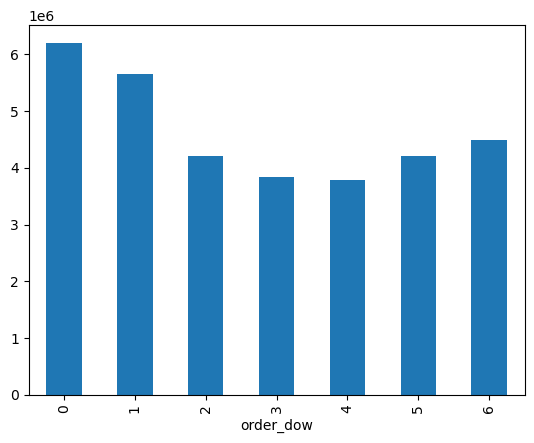

In [5]:
bar = df['order_dow'].value_counts().sort_index().plot.bar()

In [6]:
bar.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'order_dow.png'))

In [7]:
df['order_dow'].value_counts().sort_index()

order_dow
0    6204404
1    5660456
2    4213986
3    3840701
4    3783953
5    4205906
6    4496635
Name: count, dtype: int64

##### making color

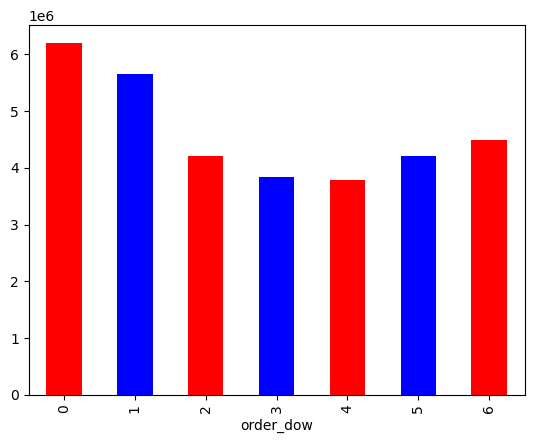

In [8]:
bar = df['order_dow'].value_counts().sort_index().plot.bar(color=['RED','blue'])

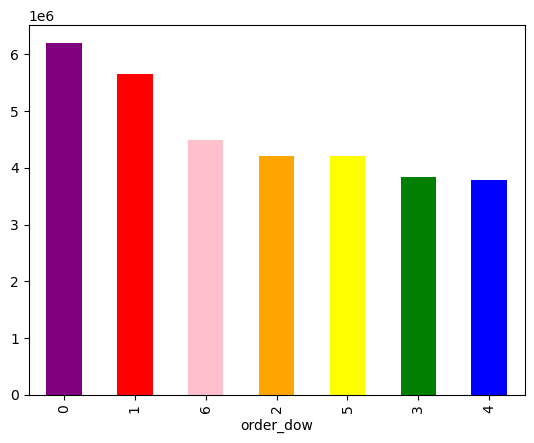

In [9]:
bar = df['order_dow'].value_counts().plot.bar(color =['purple', 'red', 'pink', 'orange', 'yellow', 'green', 'blue'])

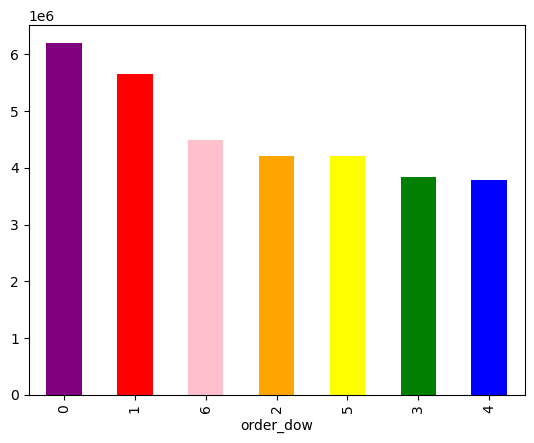

In [10]:
bar.figure

##### exporting image

In [11]:
bar.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'barchartexcercice4_9.png'))

In [12]:
df.loc[df['prices'] >100, 'prices'] = np.nan

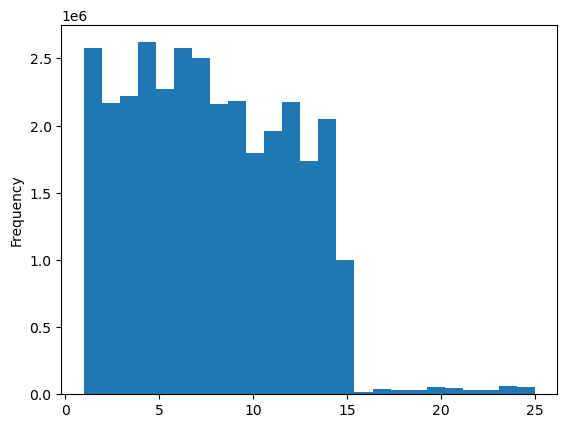

In [13]:
chart_1= df['prices'].plot.hist(bins = 25)

In [14]:
chart_1.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'chart_1.png'))

In [51]:
df['prices'].describe()

count    2.000000e+06
mean     7.751764e+00
std      4.128483e+00
min      1.000000e+00
25%      4.200000e+00
50%      7.600000e+00
75%      1.120000e+01
max      2.450000e+01
Name: prices, dtype: float64

<Axes: xlabel='prices', ylabel='prices'>

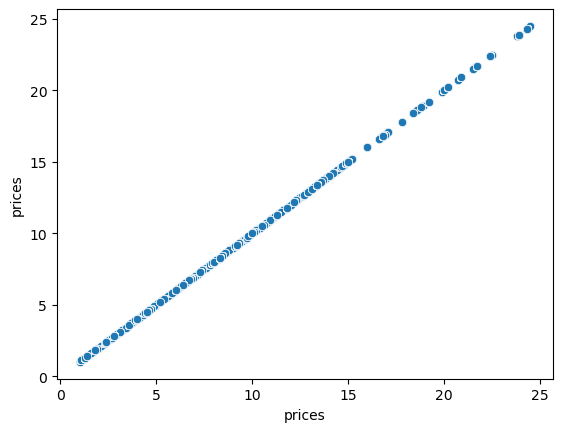

In [52]:
sns.scatterplot(x = 'prices', y = 'prices',data =df)

#### Note : before cleaning the data i found 3 points , the same in the course , then after checking the scatterplot has become like this , it s normal as long as we have cross-referenced prices and the data is clean, this is the same for the first bar chart

In [53]:
df['prices'].max()

24.5

####  creating subset with 20000000 rows

##### Note : I'm experiencing memory allocation difficulties despite my PC's high performance; that's why I was forced to allocate only 2 million rows.

In [54]:
df = grouping_data_order_product[:2000000]

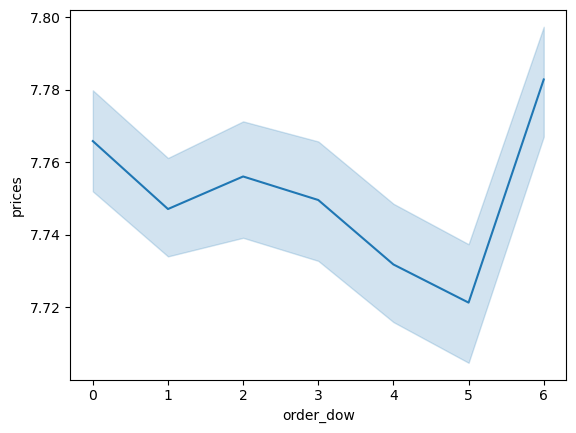

In [69]:
line_0= sns.lineplot(data=df, x='order_dow', y='prices')


In [70]:
line_0.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'line_chart2_M.png'))

#### creating sample

In [56]:
np.random.seed(4)
dev = np.random.rand(len(df)) <= 0.7

In [57]:
dev

array([False,  True, False, ...,  True,  True,  True], shape=(2000000,))

### creation big and small 70/30

In [58]:
big = df[dev]
small = df[~dev]

#### executing with small 30%

In [59]:
df_2 = small[['order_dow','prices']]

##### displaying line  chart

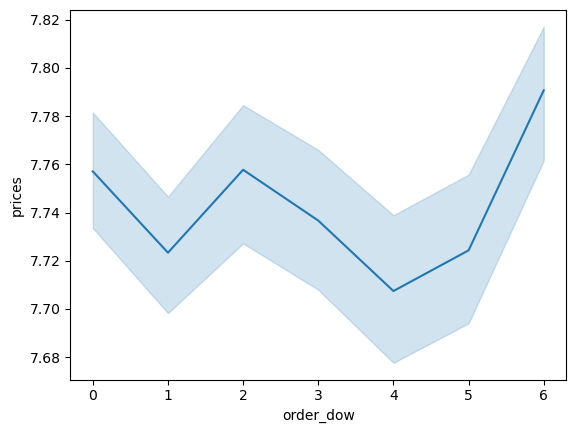

In [60]:
line = sns.lineplot(data=df_2, x='order_dow', y='prices')

### executing with big 70%

In [61]:
df_3 = big[['order_dow','prices']]

##### displaying line  chart

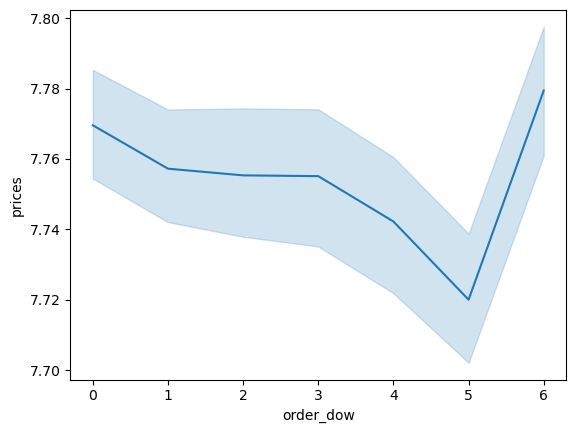

In [62]:
line_2 = sns.lineplot(data=df_3, x='order_dow', y='prices')

#### exporting graphs

##### ex big

In [66]:
line_2.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'line_chart70.png'))

##### ex small

In [67]:
line.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'line_chart30.png'))